# Notebook 03 — Clustering & Cell Type Annotation

**Goal:** Identify distinct cell populations in the UMAP and annotate them with biological cell type labels.

## Overview

This is the core biological analysis of a scRNA-seq experiment.  
We use **Leiden algorithm** (graph-based clustering) to group cells with similar transcriptional profiles, then assign biological labels using:

1. **Marker gene expression** (from van Galen 2019, Table S2)
2. **van Galen's own annotations** (available in `.obs['CellType']` from the anno files)
3. **Gene scoring** (automated scoring using `src/utils.py`)

## AML cell types in the hierarchy (van Galen 2019)

```
HSC → Progenitor → GMP → Promono → Mono
                ↘ Erythroid
                ↘ Platelet/MEP
Malignant cells = blocked at one of these stages
```

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from src.utils import (
    run_leiden_clustering,
    score_cell_types,
    assign_cell_type_from_scores,
    AML_MARKER_GENES,
    set_plot_style
)

set_plot_style()
sc.settings.verbosity = 1

In [2]:
# Load preprocessed data from notebook 02
adata = sc.read_h5ad('../data/raw/adata_02_preprocessed.h5ad')
print(f"Loaded: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Columns in .obs: {adata.obs.columns.tolist()}")

Loaded: 5996 cells × 17897 genes
Columns in .obs: ['NumberOfReads', 'AlignedToGenome', 'AlignedToTranscriptome', 'TranscriptomeUMIs', 'NumberOfGenes', 'CyclingScore', 'CyclingBinary', 'MutTranscripts', 'WtTranscripts', 'PredictionRF2', 'PredictionRefined', 'CellType', 'Score_HSC', 'Score_Prog', 'Score_GMP', 'Score_ProMono', 'Score_Mono', 'Score_cDC', 'Score_pDC', 'Score_earlyEry', 'Score_lateEry', 'Score_ProB', 'Score_B', 'Score_Plasma', 'Score_T', 'Score_CTL', 'Score_NK', 'sample', 'is_aml', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes']


## 3.1 — Leiden Clustering

Leiden is a graph-based clustering algorithm:
1. Build KNN graph (already done in notebook 02)
2. Optimize a modularity function to find communities

`resolution` controls granularity:
- Low (0.3): few, broad clusters
- High (1.5): many, fine-grained clusters

For AML cell type deconvolution, 0.4–0.8 is usually appropriate.

In [3]:
adata = run_leiden_clustering(adata, resolution=0.5)

/Users/jess/Documents/Data Projects/Projets Github/aml-scrna-landscape/notebooks/../src/utils.py:362: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added="leiden")


Leiden clustering done: 9 clusters (resolution=0.5)


In [ ]:
# UMAP colored by Leiden cluster
sc.pl.umap(adata, color='leiden', legend_loc='on data', title='Leiden Clusters')
plt.savefig('../figures/03_umap_leiden.png', dpi=150, bbox_inches='tight')

## 3.2 — Van Galen Cell Type Labels

The authors of GSE116256 provided their own cell type annotations.  
These should be in `.obs['CellType']` (loaded from the `.anno.txt.gz` files).  
We compare these expert labels to our clustering.

In [4]:
# Check if van Galen annotations are present
if 'CellType' in adata.obs.columns:
    print("Van Galen CellType labels found!")
    print(adata.obs['CellType'].value_counts())
else:
    print("CellType column not found — check that anno files were loaded correctly.")
    print(f"Available columns: {adata.obs.columns.tolist()}")

Van Galen CellType labels found!
CellType
HSC             1242
GMP-like        1231
Prog-like        742
Prog             699
ProMono-like     501
GMP              132
earlyEry         124
Mono-like        105
ProB              93
Mono              85
cDC-like          57
HSC-like          43
lateEry           39
ProMono           36
T                 27
cDC               19
pDC               17
Plasma            10
CTL                8
B                  2
NK                 1
Name: count, dtype: int64


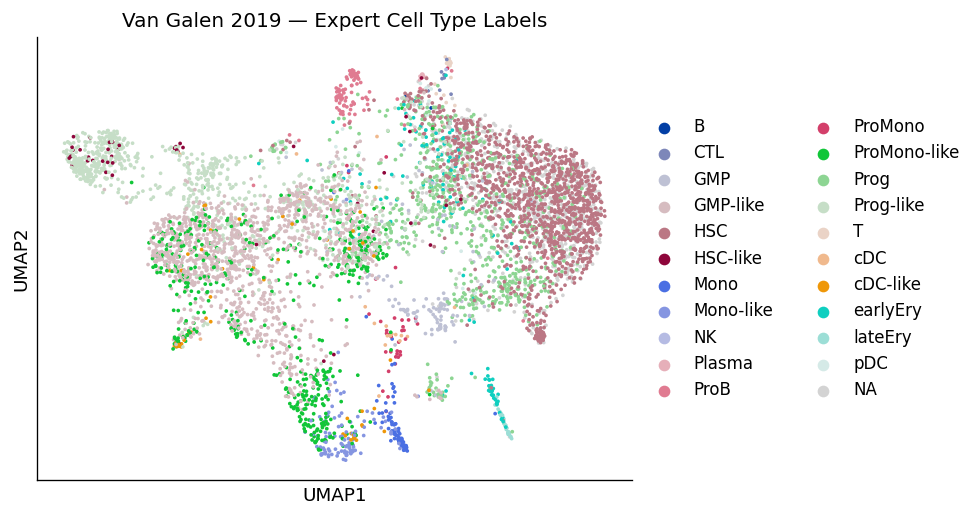

<Figure size 768x576 with 0 Axes>

In [5]:
# If van Galen labels exist, plot them on UMAP
if 'CellType' in adata.obs.columns:
    sc.pl.umap(
        adata,
        color='CellType',
        title='Van Galen 2019 — Expert Cell Type Labels',
        legend_loc='right margin'
    )
    plt.savefig('../figures/03_umap_van_galen_labels.png', dpi=150, bbox_inches='tight')

## 3.3 — Marker Gene Visualization

We plot key marker genes for each cell type on the UMAP to validate cluster identities.  
These are the canonical markers from van Galen 2019 Table S2.

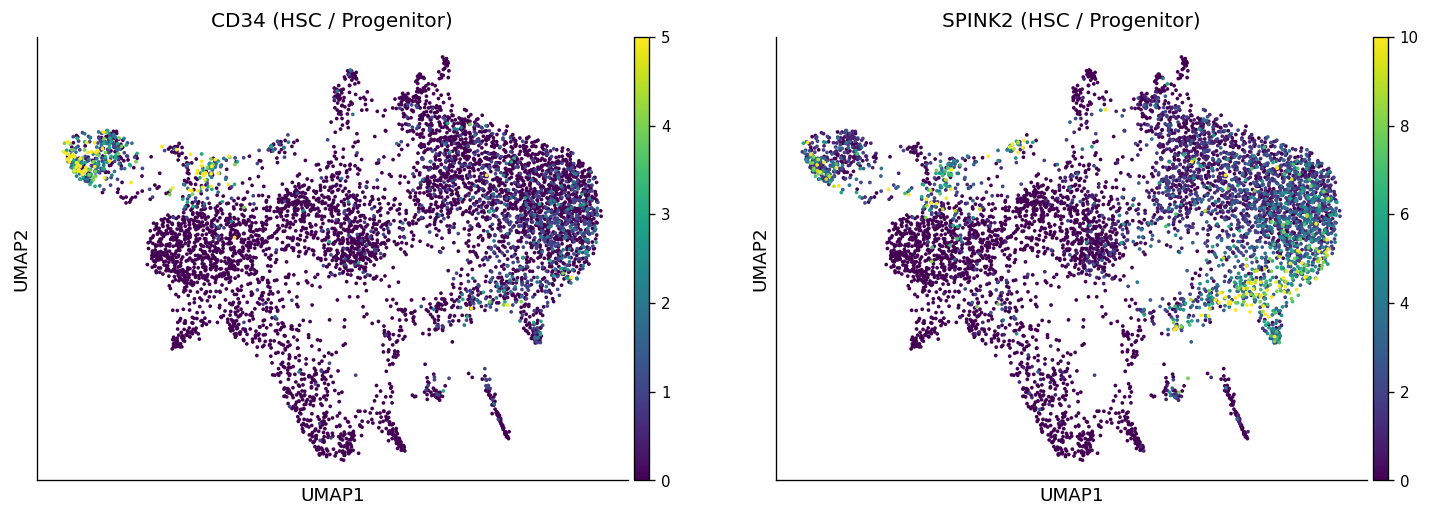

<Figure size 768x576 with 0 Axes>

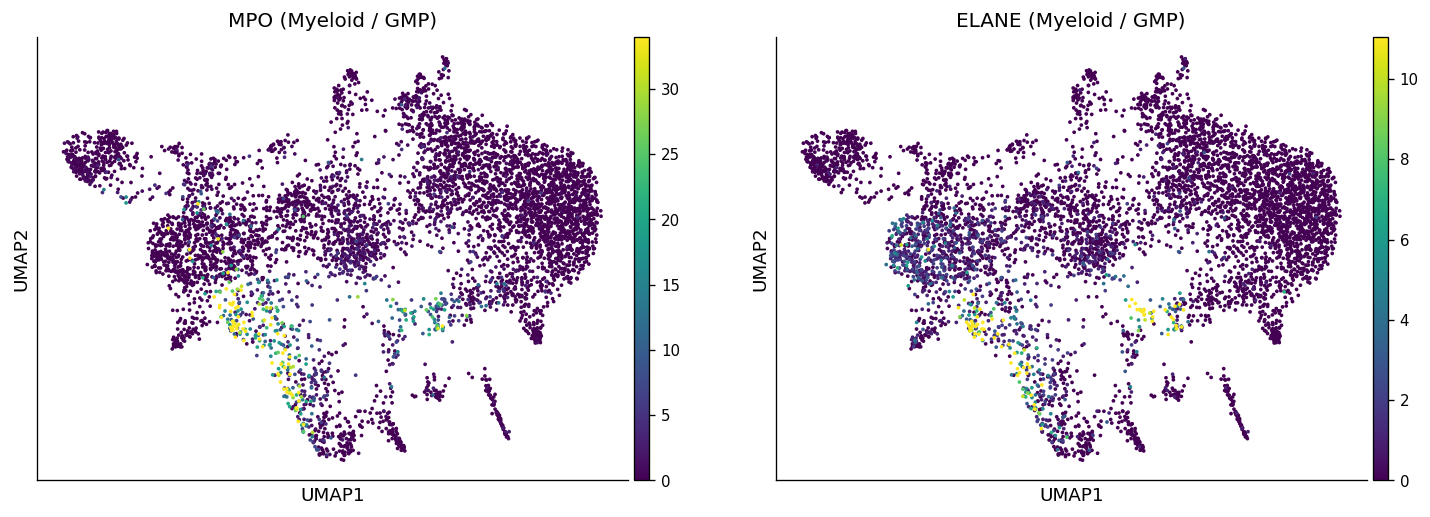

<Figure size 768x576 with 0 Axes>

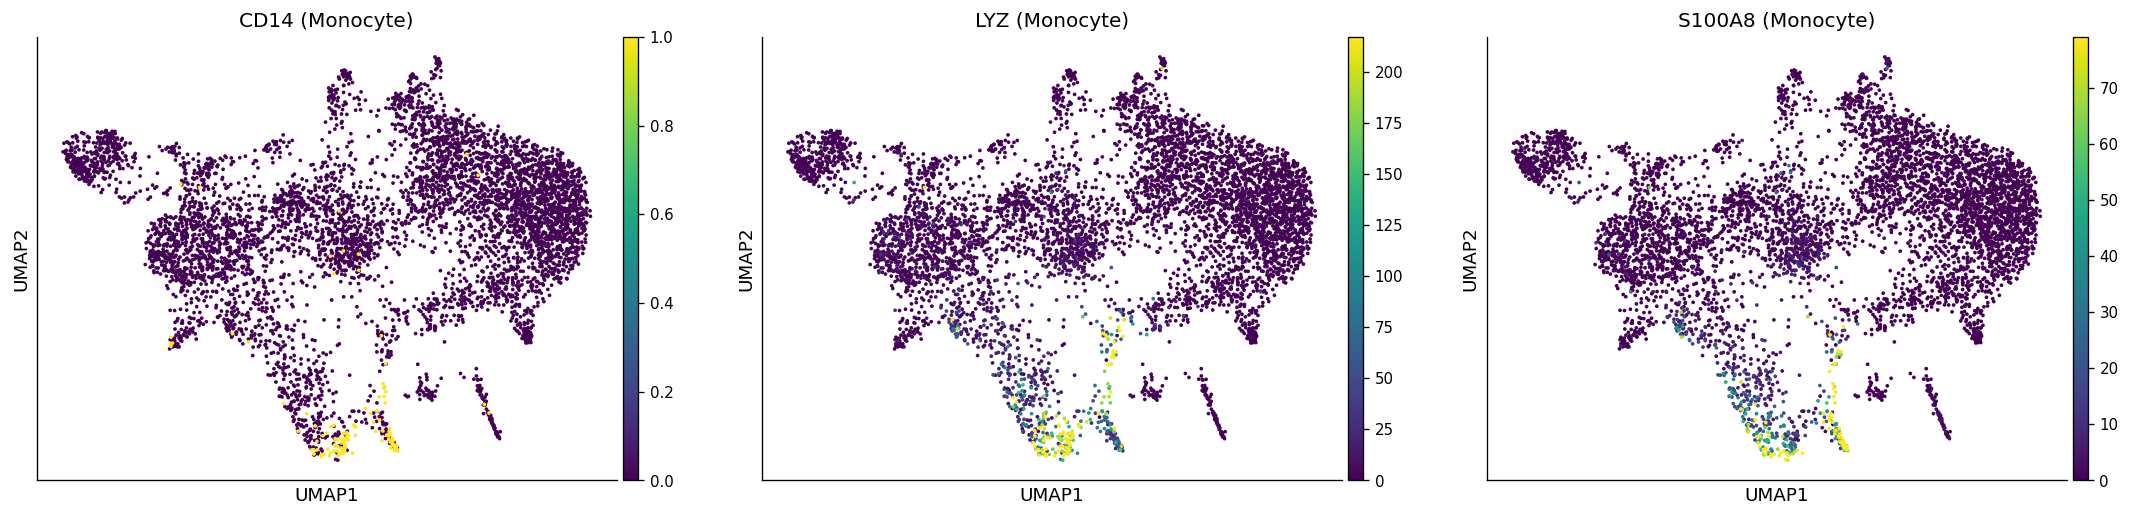

<Figure size 768x576 with 0 Axes>

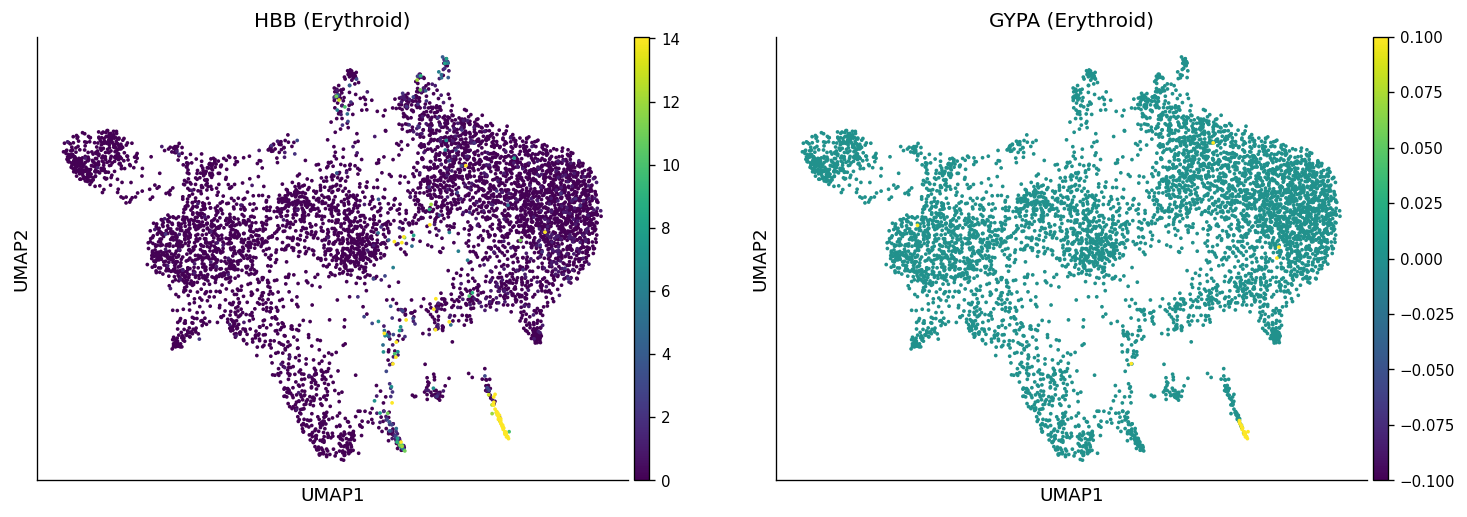

<Figure size 768x576 with 0 Axes>

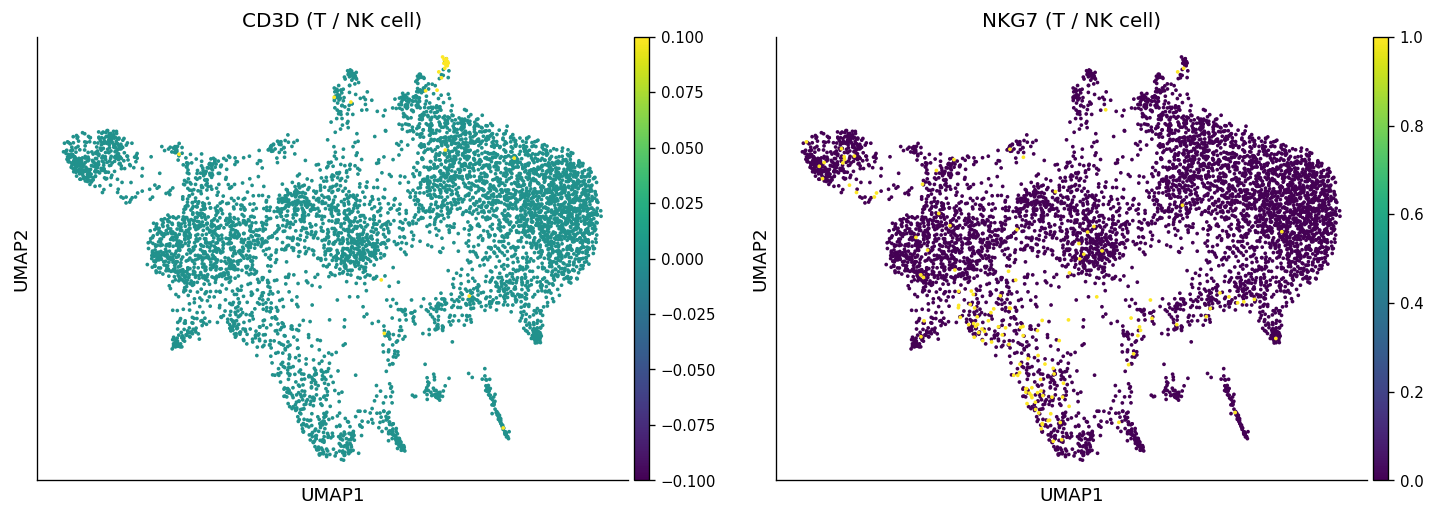

<Figure size 768x576 with 0 Axes>

In [6]:
# Key markers per cell type — a subset for visualization
key_markers = {
    'HSC / Progenitor': ['CD34', 'SPINK2'],
    'Myeloid / GMP':    ['MPO', 'ELANE'],
    'Monocyte':         ['CD14', 'LYZ', 'S100A8'],
    'Erythroid':        ['HBB', 'GYPA'],
    'T / NK cell':      ['CD3D', 'NKG7'],
}

for cell_type, genes in key_markers.items():
    # Keep only genes present in the dataset
    available = [g for g in genes if g in adata.var_names]
    if available:
        sc.pl.umap(
            adata, color=available,
            title=[f'{g} ({cell_type})' for g in available],
            use_raw=True, vmax='p99'
        )
        plt.savefig(f'../figures/03_umap_markers_{cell_type.replace(" / ", "_").replace(" ", "_")}.png',
                    dpi=100, bbox_inches='tight')

## 3.4 — Differential Expression per Cluster

Find top marker genes for each Leiden cluster using Wilcoxon rank-sum test.  
This helps manually annotate clusters that don't have pre-existing labels.

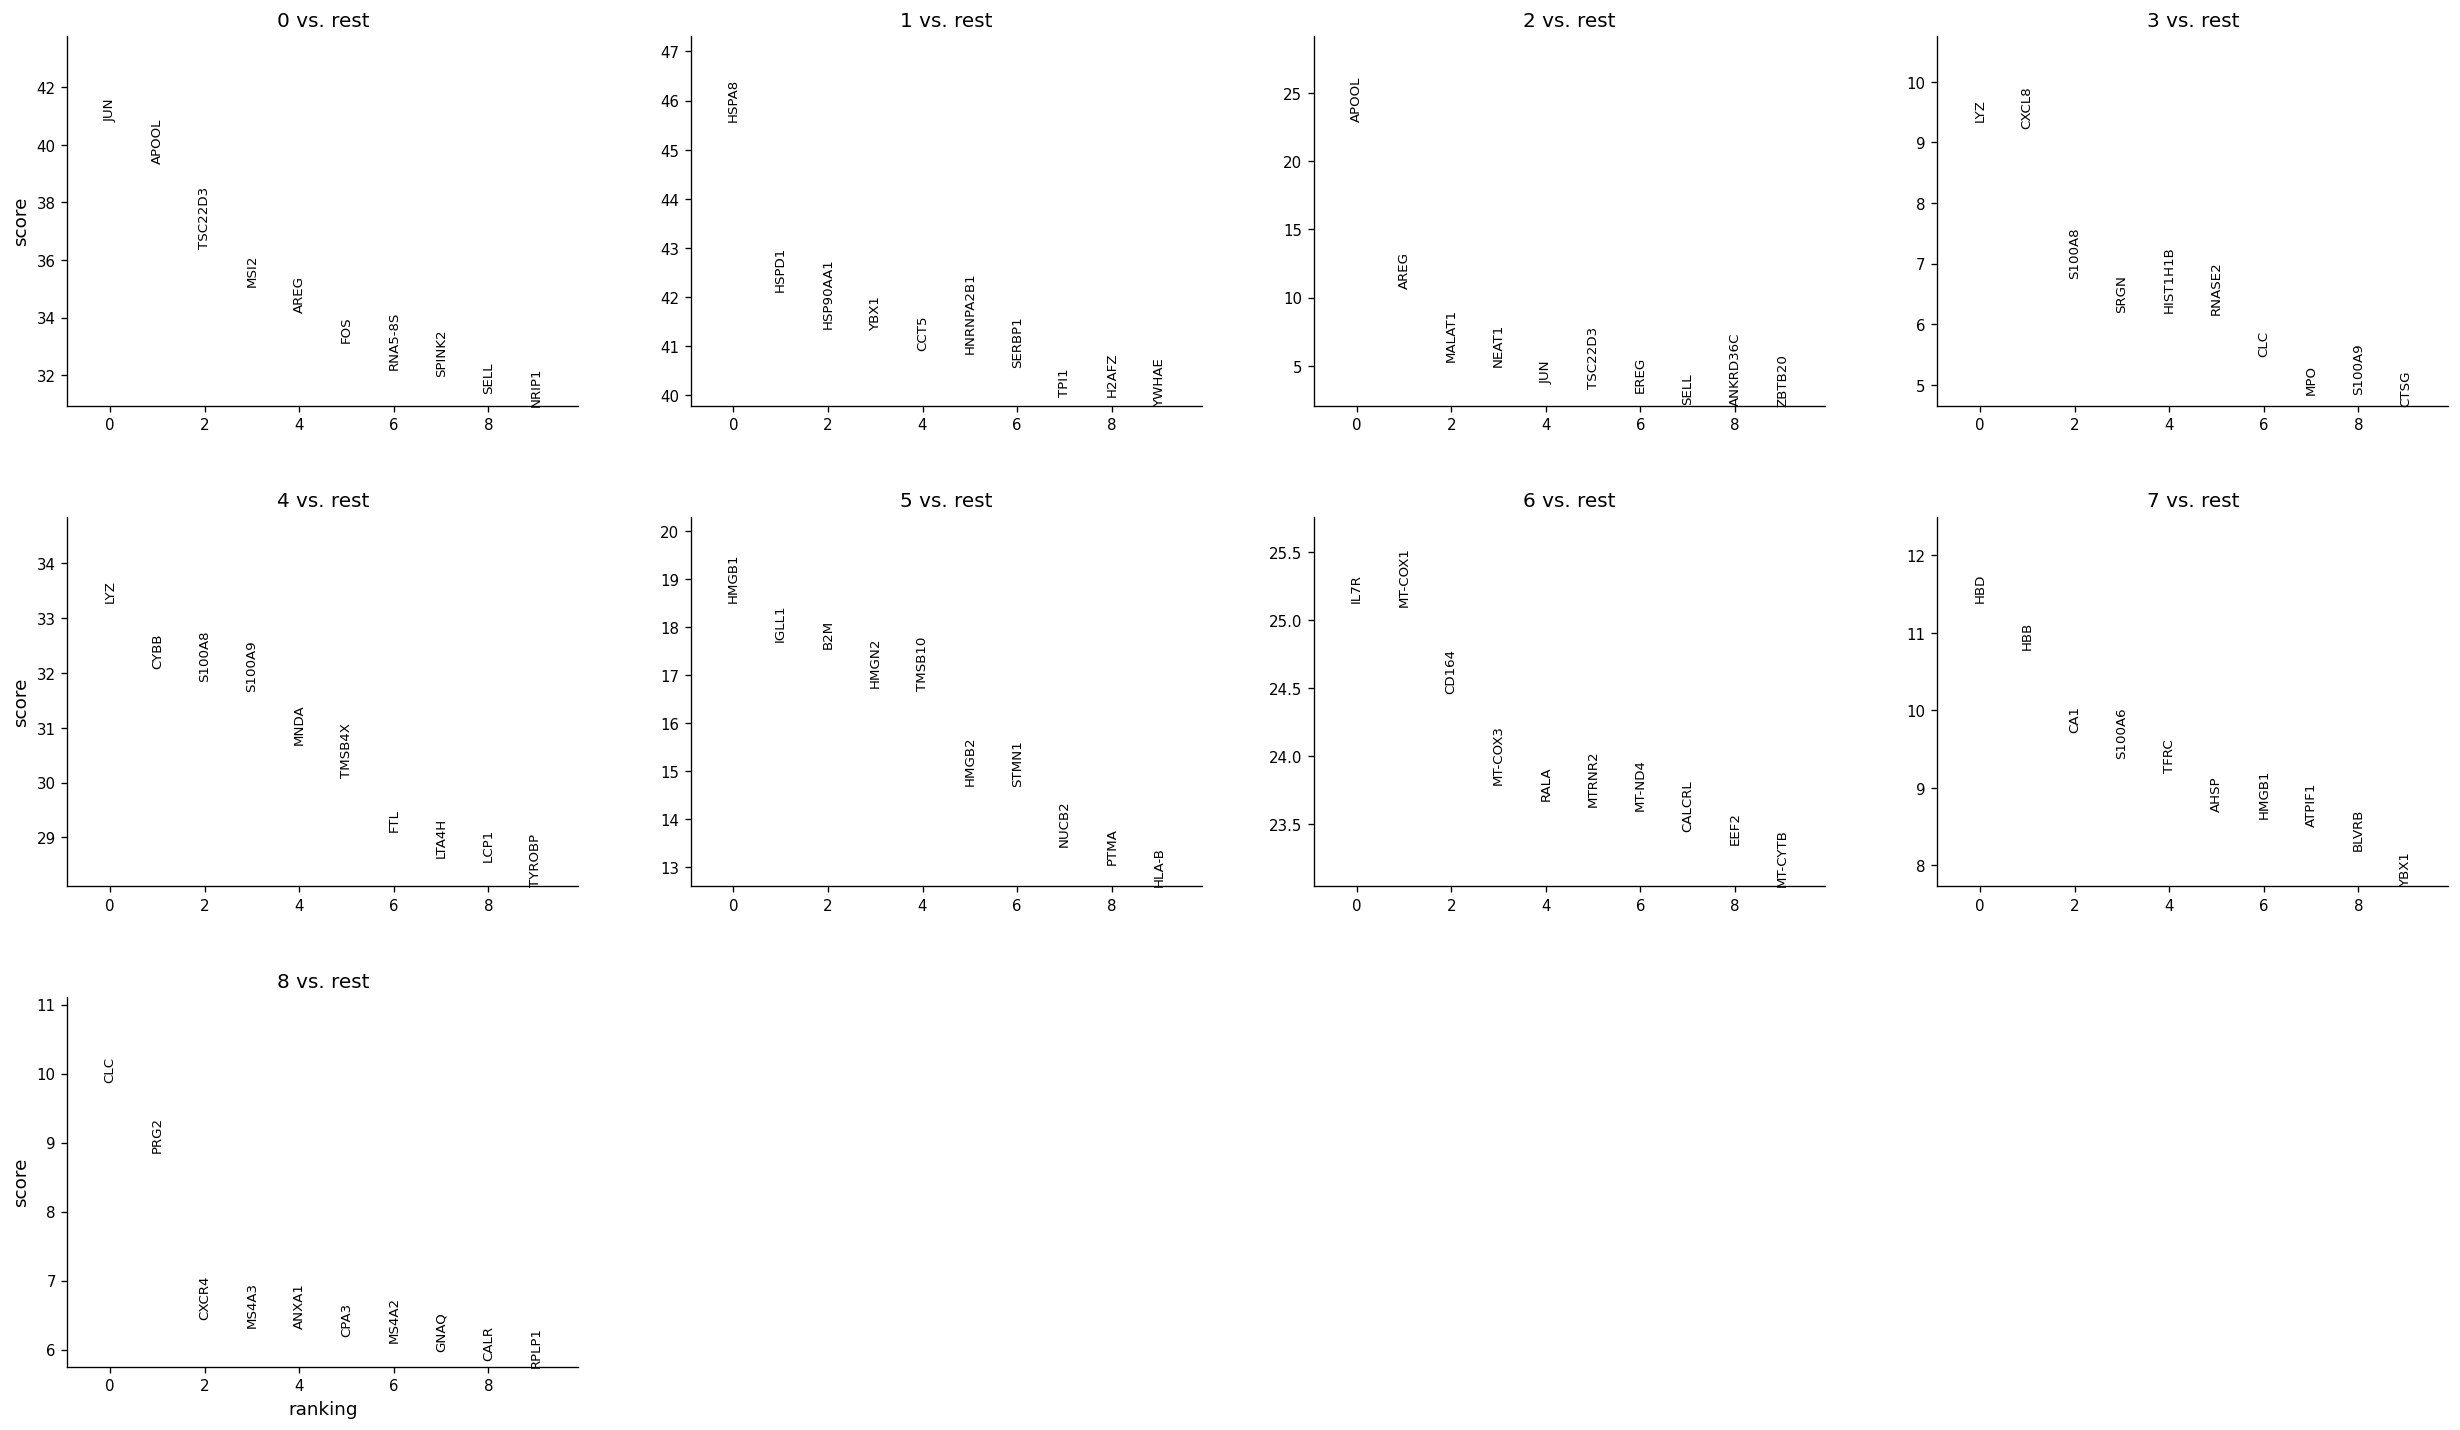

<Figure size 768x576 with 0 Axes>

In [7]:
# Compute differentially expressed genes per cluster
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)
plt.savefig('../figures/03_cluster_marker_genes.png', dpi=150, bbox_inches='tight')

In [8]:
# Top 5 marker genes per cluster as DataFrame
top_markers = sc.get.rank_genes_groups_df(adata, group=None)
top_markers_per_cluster = (
    top_markers.groupby('group')
    .apply(lambda x: x.nlargest(5, 'scores'))
    .reset_index(drop=True)
)
print(top_markers_per_cluster[['group', 'names', 'scores', 'pvals_adj']].to_string())

   group     names     scores      pvals_adj
0      0       JUN  40.810040   0.000000e+00
1      0     APOOL  39.360199   0.000000e+00
2      0   TSC22D3  36.426819  9.557588e-287
3      0      MSI2  35.107498  2.317522e-266
4      0      AREG  34.173206  2.164701e-252
5      1     HSPA8  45.576355   0.000000e+00
6      1     HSPD1  42.131470   0.000000e+00
7      1  HSP90AA1  41.361526   0.000000e+00
8      1      YBX1  41.327965   0.000000e+00
9      1      CCT5  40.922821   0.000000e+00
10     2     APOOL  22.901781  6.822446e-114
11     2      AREG  10.692760   2.215412e-25
12     2    MALAT1   5.356719   5.678458e-07
13     2     NEAT1   4.950099   4.515378e-06
14     2       JUN   3.722575   8.905652e-04
15     3       LYZ   9.346756   2.575599e-19
16     3     CXCL8   9.243239   6.666627e-19
17     3    S100A8   6.761869   1.891377e-10
18     3      SRGN   6.199926   6.651300e-09
19     3  HIST1H1B   6.189384   7.093003e-09
20     4       LYZ  33.294670  8.253236e-239
21     4  

/var/folders/cv/9vy8yk7x1s73_8cbwdkqfldh0000gn/T/ipykernel_22150/934499259.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_markers.groupby('group')
/var/folders/cv/9vy8yk7x1s73_8cbwdkqfldh0000gn/T/ipykernel_22150/934499259.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'scores'))


## 3.5 — Automated Cell Type Scoring

We use our `score_cell_types()` utility to score each cell against each cell type's marker genes.  
Then assign the highest-scoring label as the predicted cell type.

In [9]:
adata = score_cell_types(adata)
adata = assign_cell_type_from_scores(adata)

print("Predicted cell type distribution:")
print(adata.obs['predicted_cell_type'].value_counts())

Cell type scoring done.
Predicted cell type distribution:
predicted_cell_type
HSC             1123
Malignant        833
T cell           680
Promono          633
Mono             552
pDC              404
cDC              381
B cell           315
GMP              298
Platelet MEP     260
Progenitor       212
NK cell          180
Erythroid        125
Name: count, dtype: int64


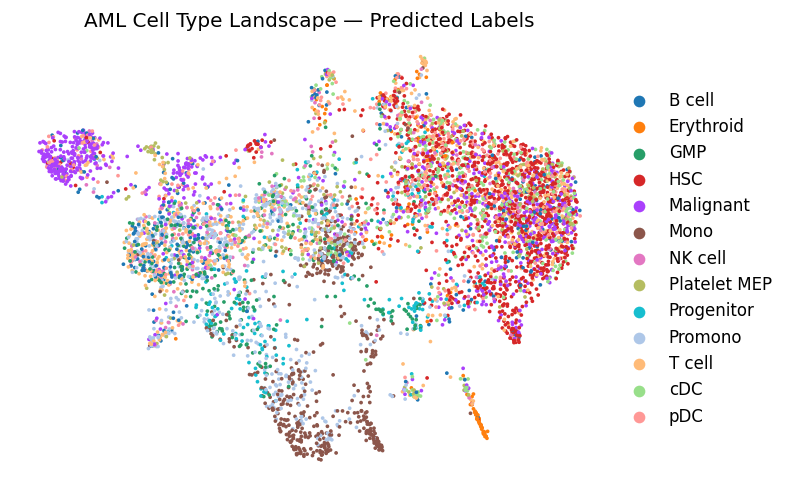

<Figure size 768x576 with 0 Axes>

In [10]:
# Final UMAP with predicted labels
sc.pl.umap(
    adata,
    color='predicted_cell_type',
    title='AML Cell Type Landscape — Predicted Labels',
    legend_loc='right margin',
    frameon=False
)
plt.savefig('../figures/03_umap_predicted_cell_types.png', dpi=150, bbox_inches='tight')

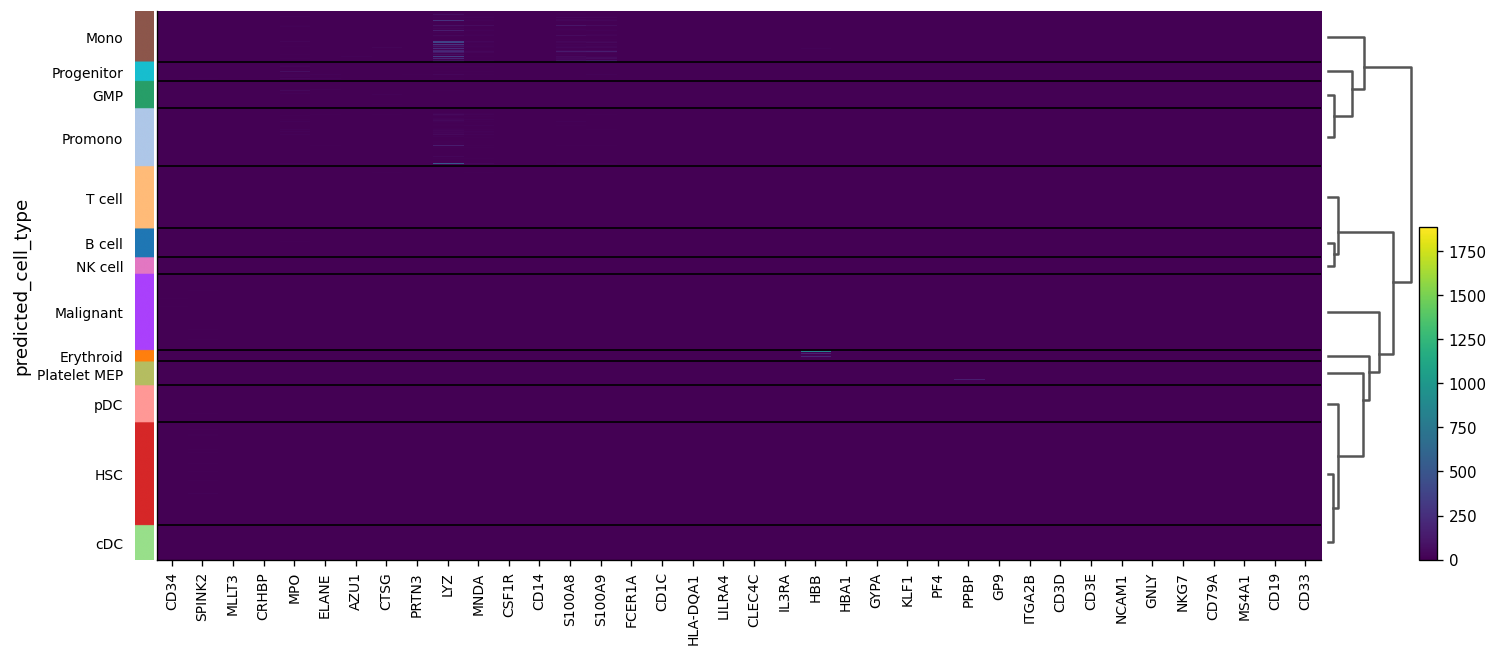

<Figure size 768x576 with 0 Axes>

In [11]:
# Heatmap: top marker genes per predicted cell type
all_markers = [g for genes in AML_MARKER_GENES.values() for g in genes if g in adata.var_names]
sc.pl.heatmap(
    adata,
    var_names=list(dict.fromkeys(all_markers)),  # deduplicate while preserving order
    groupby='predicted_cell_type',
    use_raw=True,
    dendrogram=True,
    figsize=(14, 6)
)
plt.savefig('../figures/03_marker_heatmap.png', dpi=150, bbox_inches='tight')

In [12]:
# Save annotated object
adata.write('../data/raw/adata_03_annotated.h5ad')
print("Saved: ../data/raw/adata_03_annotated.h5ad")

Saved: ../data/raw/adata_03_annotated.h5ad


## Summary

At this stage we have:
- Leiden clusters with marker gene assignments
- Van Galen expert labels (from paper)
- Automated cell type scores

Cross-checking between these three annotation strategies gives biological confidence.

**Next:** Notebook 04 — Pseudotime trajectory analysis (PAGA + DPT).